# Flight data: SFO

## Project Description



### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline

### Data ingestion

In [2]:
# Ingesting flight data for SFO
# Departures
# Airlines: Alaskan Airlines, American Airlines, Delta Airlines, Frontier Airlines
# 2022 - 2026
SFO_flights_files = sorted(glob.glob("Data_extraction/SFO_*_Departures.csv"))

for f in SFO_flights_files:
    print(" ", f)

SFO_flights = pd.concat(
    (pd.read_csv(f, skiprows=7) for f in SFO_flights_files), ignore_index=True)
print(f"Total flight rows loaded: {len(SFO_flights)}")

  Data_extraction/SFO_AA_Departures.csv
  Data_extraction/SFO_AS_Departures.csv
  Data_extraction/SFO_DL_Departures.csv
  Data_extraction/SFO_F9_Departures.csv
Total flight rows loaded: 165055


### Data Preprocessing


In [3]:
#shape and dtypes for flights
print("Shape of flights df:", SFO_flights.shape)
print("Data types:")
print(SFO_flights.dtypes)
SFO_flights.head()

Shape of flights df: (165055, 17)
Data types:
Carrier Code                                 object
Date (MM/DD/YYYY)                            object
Flight Number                               float64
Tail Number                                  object
Destination Airport                          object
Scheduled departure time                     object
Actual departure time                        object
Scheduled elapsed time (Minutes)            float64
Actual elapsed time (Minutes)               float64
Departure delay (Minutes)                   float64
Wheels-off time                              object
Taxi-Out time (Minutes)                     float64
Delay Carrier (Minutes)                     float64
Delay Weather (Minutes)                     float64
Delay National Aviation System (Minutes)    float64
Delay Security (Minutes)                    float64
Delay Late Aircraft Arrival (Minutes)       float64
dtype: object


,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,11:49,14.0,0.0,0.0,0.0,0.0,0.0
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,07:11,17.0,0.0,0.0,0.0,0.0,0.0
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,23:09,18.0,0.0,0.0,0.0,0.0,0.0
3,AA,01/01/2022,369.0,N341SV,MIA,07:47,07:43,330.0,303.0,-4.0,07:54,11.0,0.0,0.0,0.0,0.0,0.0
4,AA,01/01/2022,1175.0,N992AN,DFW,17:21,17:31,208.0,195.0,10.0,17:45,14.0,0.0,0.0,0.0,0.0,0.0


In [4]:
SFO_flights.to_csv("SFO_flights_combined.csv", index=False)

In [5]:
raw_df = pd.read_csv('Data_extraction/SFO_flights_combined.csv')

raw_df = raw_df[
    ~raw_df['Carrier Code'].str.strip().str.startswith('SOURCE')
].reset_index(drop=True)

print(f'# of Rows: {len(raw_df):,}')
print(f'Airlines we included: {sorted(raw_df["Carrier Code"].unique())}')
raw_df.head(3)

# of Rows: 165,051
Airlines we included: ['AA', 'AS', 'DL', 'F9']


,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,11:49,14.0,0.0,0.0,0.0,0.0,0.0
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,07:11,17.0,0.0,0.0,0.0,0.0,0.0
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,23:09,18.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#copy of raw df so we don't modify the raw data
mod_df = raw_df.copy()


In [7]:
#creating the is_cancelled column
mod_df['is_cancelled'] = (mod_df['Actual elapsed time (Minutes)'] == 0).astype(int)

In [8]:
mod_df.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes),is_cancelled
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,11:49,14.0,0.0,0.0,0.0,0.0,0.0,0
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,07:11,17.0,0.0,0.0,0.0,0.0,0.0,0
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,23:09,18.0,0.0,0.0,0.0,0.0,0.0,0
3,AA,01/01/2022,369.0,N341SV,MIA,07:47,07:43,330.0,303.0,-4.0,07:54,11.0,0.0,0.0,0.0,0.0,0.0,0
4,AA,01/01/2022,1175.0,N992AN,DFW,17:21,17:31,208.0,195.0,10.0,17:45,14.0,0.0,0.0,0.0,0.0,0.0,0


In [9]:
#creating the 3 classes
mod_df['outcome'] = np.where(
    mod_df['is_cancelled'] == 1, 2,
    np.where(mod_df['Departure delay (Minutes)'] > 15, 1, 0))

mod_df['departure_delay_min'] = np.where(
    mod_df['is_cancelled'] == 1, np.nan, mod_df['Departure delay (Minutes)'])

labels = {0: 'On time or early', 1: 'Delayed more than 15 min', 2: 'Cancelled'}
counts = mod_df['outcome'].value_counts().sort_index()
print('Outcome distribution:')
for k, v in counts.items():
    print(f'  {labels[k]}: {v:,}' )

Outcome distribution:
  On time or early: 129,778
  Delayed more than 15 min: 32,487
  Cancelled: 2,786


In [10]:
mod_df.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes),is_cancelled,outcome,departure_delay_min
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,11:49,14.0,0.0,0.0,0.0,0.0,0.0,0,0,-11.0
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,07:11,17.0,0.0,0.0,0.0,0.0,0.0,0,0,-6.0
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,23:09,18.0,0.0,0.0,0.0,0.0,0.0,0,0,-8.0
3,AA,01/01/2022,369.0,N341SV,MIA,07:47,07:43,330.0,303.0,-4.0,07:54,11.0,0.0,0.0,0.0,0.0,0.0,0,0,-4.0
4,AA,01/01/2022,1175.0,N992AN,DFW,17:21,17:31,208.0,195.0,10.0,17:45,14.0,0.0,0.0,0.0,0.0,0.0,0,0,10.0


In [11]:
#combing date and time to a proper datetime field 
mod_df['scheduled_dep_dt'] = pd.to_datetime(
    mod_df['Date (MM/DD/YYYY)'] + ' ' + mod_df['Scheduled departure time'],
    format='%m/%d/%Y %H:%M',
    errors='coerce')
mod_df['date'] = pd.to_datetime(mod_df['Date (MM/DD/YYYY)'], format='%m/%d/%Y')

#only using data available upto 6 hours before the flight is scheduled to depart
mod_df['6hr_cutoff_dt'] = mod_df['scheduled_dep_dt'] - pd.Timedelta(hours=6)


In [12]:
mod_df.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),...,Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes),is_cancelled,outcome,departure_delay_min,scheduled_dep_dt,date,6hr_cutoff_dt
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,...,0.0,0.0,0.0,0.0,0,0,-11.0,2022-01-01 11:46:00,2022-01-01,2022-01-01 05:46:00
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,...,0.0,0.0,0.0,0.0,0,0,-6.0,2022-01-01 07:00:00,2022-01-01,2022-01-01 01:00:00
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,...,0.0,0.0,0.0,0.0,0,0,-8.0,2022-01-01 22:59:00,2022-01-01,2022-01-01 16:59:00
3,AA,01/01/2022,369.0,N341SV,MIA,07:47,07:43,330.0,303.0,-4.0,...,0.0,0.0,0.0,0.0,0,0,-4.0,2022-01-01 07:47:00,2022-01-01,2022-01-01 01:47:00
4,AA,01/01/2022,1175.0,N992AN,DFW,17:21,17:31,208.0,195.0,10.0,...,0.0,0.0,0.0,0.0,0,0,10.0,2022-01-01 17:21:00,2022-01-01,2022-01-01 11:21:00


In [13]:
mod_df.columns = (
    mod_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s\(\)/]+', '_', regex=True)
    .str.replace(r'[^\w]', '', regex=True)
    .str.strip('_')
)

In [14]:
#missing value summary
missing = mod_df.isna().sum()
missing_percent = (missing / len(mod_df) * 100).round(2)
summary = (
    pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
    .query('missing_count > 0')
    .sort_values('missing_percent', ascending=False)
)
print(f'Columns with missing values ({len(summary)} of {len(mod_df.columns)}):')
summary

Columns with missing values (2 of 23):


,missing_count,missing_percent
departure_delay_min,2786,1.69
tail_number,292,0.18


In [15]:
#cause of delay counts
cause_cols = ['delay_carrier_minutes',
    'delay_weather_minutes',
    'delay_national_aviation_system_minutes',
    'delay_security_minutes',
    'delay_late_aircraft_arrival_minutes']

op = mod_df[mod_df['is_cancelled'] == 0]
for c in cause_cols:
    n = (op[c] > 0).sum()
    total = op[c].sum()
    print(f'  {c}: {n} flights, {total} total minutes')

  delay_carrier_minutes: 14046 flights, 882279.0 total minutes
  delay_weather_minutes: 775 flights, 47451.0 total minutes
  delay_national_aviation_system_minutes: 17790 flights, 441641.0 total minutes
  delay_security_minutes: 88 flights, 3066.0 total minutes
  delay_late_aircraft_arrival_minutes: 17583 flights, 1154618.0 total minutes


# Feature Engineering

In [16]:
#relevant datetime features
mod_df['year'] = mod_df['date'].dt.year
mod_df['month'] = mod_df['date'].dt.month
mod_df['day_of_week'] = mod_df['date'].dt.dayofweek
mod_df['is_weekend'] = (mod_df['day_of_week'] >= 5).astype(int)
mod_df['sched_dep_hour'] = mod_df['scheduled_dep_dt'].dt.hour

In [17]:
mod_df.head()

,carrier_code,date_mm_dd_yyyy,flight_number,tail_number,destination_airport,scheduled_departure_time,actual_departure_time,scheduled_elapsed_time_minutes,actual_elapsed_time_minutes,departure_delay_minutes,...,outcome,departure_delay_min,scheduled_dep_dt,date,6hr_cutoff_dt,year,month,day_of_week,is_weekend,sched_dep_hour
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,...,0,-11.0,2022-01-01 11:46:00,2022-01-01,2022-01-01 05:46:00,2022,1,5,1,11
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,...,0,-6.0,2022-01-01 07:00:00,2022-01-01,2022-01-01 01:00:00,2022,1,5,1,7
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,...,0,-8.0,2022-01-01 22:59:00,2022-01-01,2022-01-01 16:59:00,2022,1,5,1,22
3,AA,01/01/2022,369.0,N341SV,MIA,07:47,07:43,330.0,303.0,-4.0,...,0,-4.0,2022-01-01 07:47:00,2022-01-01,2022-01-01 01:47:00,2022,1,5,1,7
4,AA,01/01/2022,1175.0,N992AN,DFW,17:21,17:31,208.0,195.0,10.0,...,0,10.0,2022-01-01 17:21:00,2022-01-01,2022-01-01 11:21:00,2022,1,5,1,17


In [18]:
#time of day column
mod_df['dep_time_of_day'] = pd.cut(
    mod_df['sched_dep_hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['early morning', 'morning', 'afternoon', 'evening/night'],
    right=False)

In [19]:
mod_df.head()

,carrier_code,date_mm_dd_yyyy,flight_number,tail_number,destination_airport,scheduled_departure_time,actual_departure_time,scheduled_elapsed_time_minutes,actual_elapsed_time_minutes,departure_delay_minutes,...,departure_delay_min,scheduled_dep_dt,date,6hr_cutoff_dt,year,month,day_of_week,is_weekend,sched_dep_hour,dep_time_of_day
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,...,-11.0,2022-01-01 11:46:00,2022-01-01,2022-01-01 05:46:00,2022,1,5,1,11,morning
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,...,-6.0,2022-01-01 07:00:00,2022-01-01,2022-01-01 01:00:00,2022,1,5,1,7,morning
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,...,-8.0,2022-01-01 22:59:00,2022-01-01,2022-01-01 16:59:00,2022,1,5,1,22,evening/night
3,AA,01/01/2022,369.0,N341SV,MIA,07:47,07:43,330.0,303.0,-4.0,...,-4.0,2022-01-01 07:47:00,2022-01-01,2022-01-01 01:47:00,2022,1,5,1,7,morning
4,AA,01/01/2022,1175.0,N992AN,DFW,17:21,17:31,208.0,195.0,10.0,...,10.0,2022-01-01 17:21:00,2022-01-01,2022-01-01 11:21:00,2022,1,5,1,17,afternoon


In [20]:
us_holidays = pd.to_datetime([
    '2022-01-01','2023-01-01','2024-01-01','2025-01-01','2026-01-01',
    '2022-05-30','2023-05-29','2024-05-27','2025-05-26','2026-05-25',
    '2022-07-04','2023-07-04','2024-07-04','2025-07-04','2026-07-04',
    '2022-09-05','2023-09-04','2024-09-02','2025-09-01','2026-09-07',
    '2022-11-24','2023-11-23','2024-11-28','2025-11-27','2026-11-26',
    '2022-12-25','2023-12-25','2024-12-25','2025-12-25','2026-12-25',
])
mod_df['is_holiday'] = mod_df['date'].isin(us_holidays).astype(int)
print(f'Flights on holidays: {mod_df["is_holiday"].sum():,}')

Flights on holidays: 2,387


In [21]:
#strip the leading 'N' in the tail number so it matches with the aircraft dataset 
mod_df['mod_tail_number'] =mod_df['tail_number'].str.strip().str.lstrip('N')

mod_df['carrier_code']        = mod_df['carrier_code'].astype('category')
mod_df['destination_airport'] = mod_df['destination_airport'].astype('category')
mod_df['dep_time_of_day']     = mod_df['dep_time_of_day'].astype('category')

print(f'Unique carriers: {mod_df["carrier_code"].nunique()}')
print(f'Unique destinations: {mod_df["destination_airport"].nunique()}')

Unique carriers: 4
Unique destinations: 42


In [22]:
mod_df.head()

,carrier_code,date_mm_dd_yyyy,flight_number,tail_number,destination_airport,scheduled_departure_time,actual_departure_time,scheduled_elapsed_time_minutes,actual_elapsed_time_minutes,departure_delay_minutes,...,date,6hr_cutoff_dt,year,month,day_of_week,is_weekend,sched_dep_hour,dep_time_of_day,is_holiday,mod_tail_number
0,AA,01/01/2022,16.0,N110AN,JFK,11:46,11:35,343.0,328.0,-11.0,...,2022-01-01,2022-01-01 05:46:00,2022,1,5,1,11,morning,1,110AN
1,AA,01/01/2022,234.0,N112AN,JFK,07:00,06:54,329.0,328.0,-6.0,...,2022-01-01,2022-01-01 01:00:00,2022,1,5,1,7,morning,1,112AN
2,AA,01/01/2022,276.0,N109NN,JFK,22:59,22:51,333.0,329.0,-8.0,...,2022-01-01,2022-01-01 16:59:00,2022,1,5,1,22,evening/night,1,109NN
3,AA,01/01/2022,369.0,N341SV,MIA,07:47,07:43,330.0,303.0,-4.0,...,2022-01-01,2022-01-01 01:47:00,2022,1,5,1,7,morning,1,341SV
4,AA,01/01/2022,1175.0,N992AN,DFW,17:21,17:31,208.0,195.0,10.0,...,2022-01-01,2022-01-01 11:21:00,2022,1,5,1,17,afternoon,1,992AN


# EDA

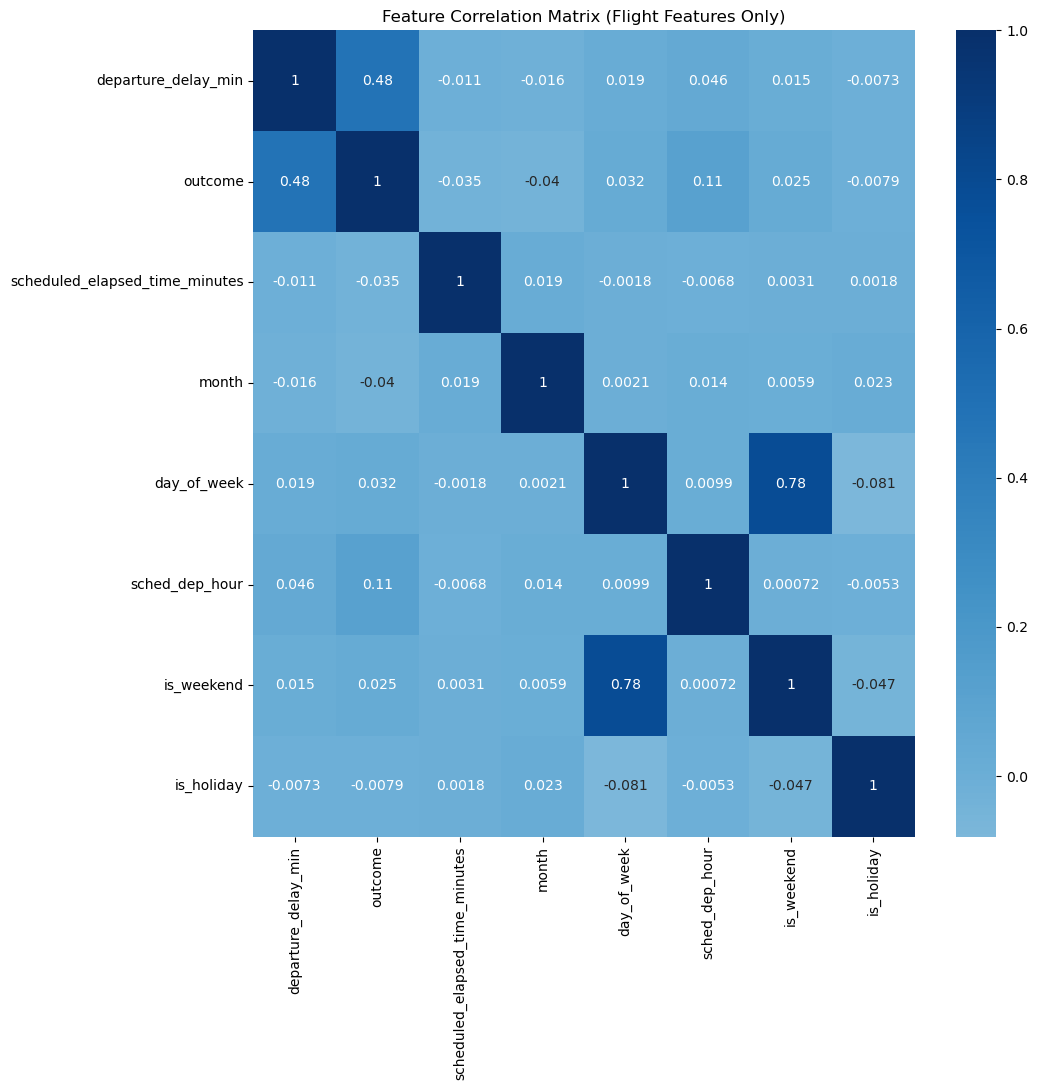

In [23]:
matrix_cols = [
    'departure_delay_min', 'outcome',
    'scheduled_elapsed_time_minutes',
    'month', 'day_of_week', 'sched_dep_hour',
    'is_weekend', 'is_holiday',
    'rolling_3h_sfo_delay', 'route_hist_mean_delay',
]
matrix_cols = [c for c in matrix_cols if c in mod_df.columns]

corr = mod_df[matrix_cols].apply(pd.to_numeric, errors='coerce').corr()

fig, ax = plt.subplots(figsize =(11,11))
sns.heatmap(corr, annot=True, cmap = 'Blues', center=0)
ax.set_title('Feature Correlation Matrix (Flight Features Only)', fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
print(op.columns.tolist())

['carrier_code', 'date_mm_dd_yyyy', 'flight_number', 'tail_number', 'destination_airport', 'scheduled_departure_time', 'actual_departure_time', 'scheduled_elapsed_time_minutes', 'actual_elapsed_time_minutes', 'departure_delay_minutes', 'wheelsoff_time', 'taxiout_time_minutes', 'delay_carrier_minutes', 'delay_weather_minutes', 'delay_national_aviation_system_minutes', 'delay_security_minutes', 'delay_late_aircraft_arrival_minutes', 'is_cancelled', 'outcome', 'departure_delay_min', 'scheduled_dep_dt', 'date', '6hr_cutoff_dt']


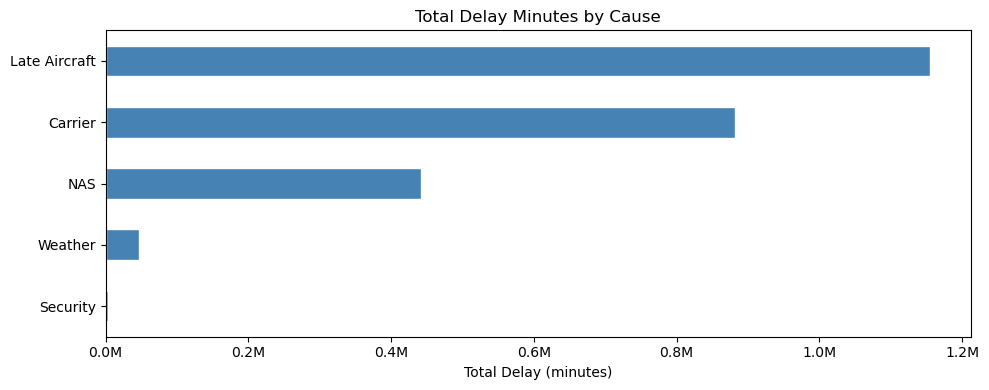

In [31]:
cause_cols = {
    'delay_carrier_minutes': 'Carrier',
    'delay_weather_minutes': 'Weather',
    'delay_national_aviation_system_minutes': 'NAS',
    'delay_security_minutes': 'Security',
    'delay_late_aircraft_arrival_minutes': 'Late Aircraft'
}

cause_totals = op[list(cause_cols.keys())].sum().rename(cause_cols)

fig, ax = plt.subplots(figsize=(10, 4))
cause_totals.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Delay Minutes by Cause', fontsize=12)
ax.set_xlabel('Total Delay (minutes)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

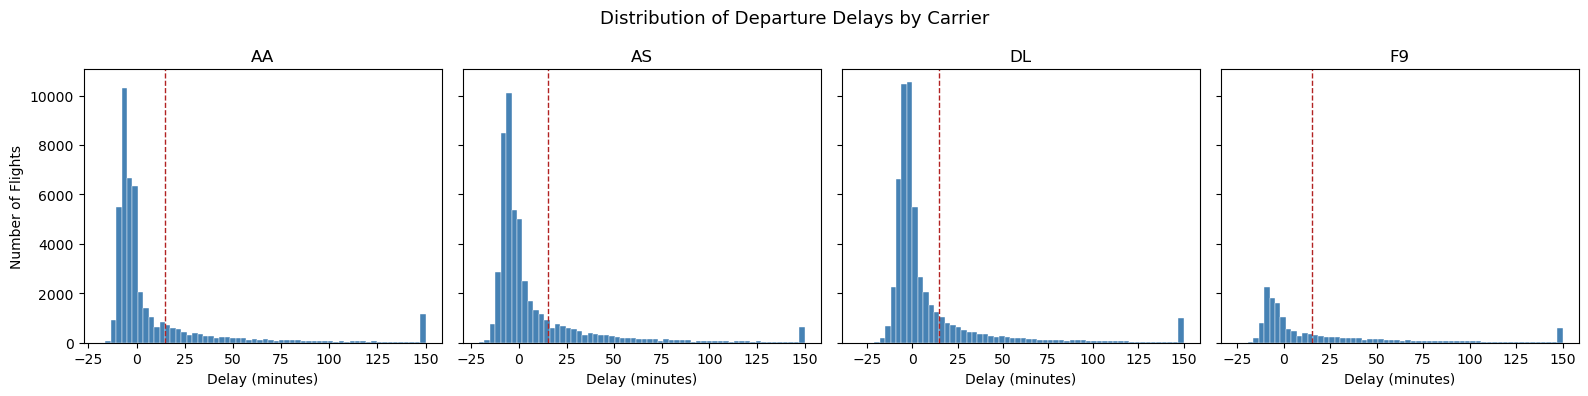

In [32]:
carriers = op['carrier_code'].unique()

fig, axes = plt.subplots(1, len(carriers), figsize=(16, 4), sharey=True)

for ax, carrier in zip(axes, carriers):
    data = op[op['carrier_code'] == carrier]['departure_delay_min'].clip(-30, 150)
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(15, color='firebrick', linestyle='--', linewidth=1)
    ax.set_title(carrier, fontsize=12)
    ax.set_xlabel('Delay (minutes)')

axes[0].set_ylabel('Number of Flights')
fig.suptitle('Distribution of Departure Delays by Carrier', fontsize=13)
plt.tight_layout()
plt.show()

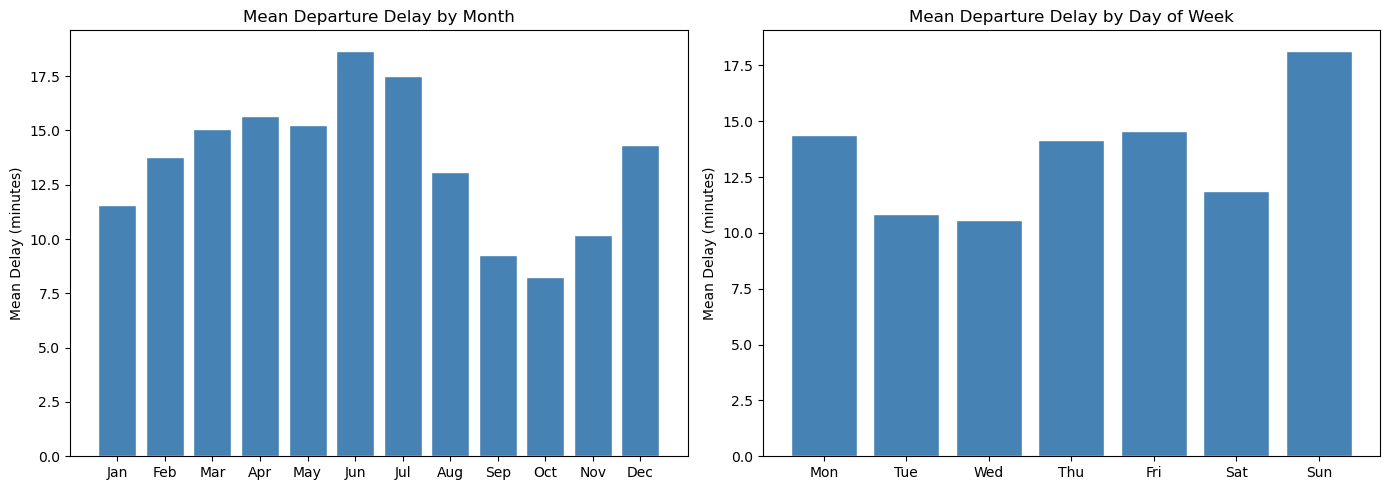

In [35]:
#dist of delay by month and day of week
op = mod_df[mod_df['is_cancelled'] == 0].copy()
op['month'] = pd.to_datetime(op['date_mm_dd_yyyy'], format='%m/%d/%Y').dt.month
op['day_of_week'] = pd.to_datetime(op['date_mm_dd_yyyy'], format='%m/%d/%Y').dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_delay = op.groupby('month')['departure_delay_min'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_delay.index, month_delay.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_title('Mean Departure Delay by Month', fontsize=12)
axes[0].set_ylabel('Mean Delay (minutes)')

dow_delay = op.groupby('day_of_week')['departure_delay_min'].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(dow_delay.index, dow_delay.values, color='steelblue', edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_title('Mean Departure Delay by Day of Week', fontsize=12)
axes[1].set_ylabel('Mean Delay (minutes)')

plt.tight_layout()
plt.show()